In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from factor_model import load_model


PREFIX     = "model/stable"
test_model = load_model(f"{PREFIX}/test")

ALL_COLS = list(test_model.F.columns)
FN       = [c for c in ALL_COLS if c != "alpha"]    # factor names, aligned to beta rows 1..K
vidx     = FN.index("value")
beta     = np.asarray(test_model.beta)              # (1+K, S): row 0 = alpha/intercept
Fac      = test_model.F[FN].to_numpy()              # (T, K) daily factor returns
fdates   = pd.to_datetime(test_model.F.index).normalize()
print("factors:", FN, "| value idx:", vidx, "| beta:", beta.shape)


df = pd.read_parquet("data/downstream2025.parquet").dropna(subset=["mcap"]).copy()
df["date"] = pd.to_datetime(df["date"]).dt.normalize()

gics_map = {10:"Energy", 15:"Materials", 20:"Industrials", 25:"Consumer Discretionary",
            30:"Consumer Staples", 35:"Health Care", 40:"Financials",
            45:"Information Technology", 50:"Communication Services",
            55:"Utilities", 60:"Real Estate"}
df["gics_name"] = df["gics"].astype(int).map(gics_map)


sids = sorted(df["csecid"].unique())
col  = {c: i for i, c in enumerate(sids)}
assert len(sids) == beta.shape[1], (len(sids), beta.shape[1])
print("stocks:", len(sids), "| dates:", df.date.nunique(),
      "|", df.date.min().date(), "->", df.date.max().date())


SHOCK   = -0.30
HORIZON = 22


factors: ['market', 'growth', 'momentum', 'quality', 'size', 'value', 'volatility'] | value idx: 5 | beta: (8, 1979)
stocks: 1979 | dates: 261 | 2025-01-01 -> 2025-12-31


In [2]:
def rolling_stress(model_beta, Fac, fdates, df, sids, vidx,
                   shock=SHOCK, horizon=HORIZON):
    col        = {c: i for i, c in enumerate(sids)}
    day_groups = dict(tuple(df.groupby("date")))

    daily_rows, sector_rows = [], []
    for i, t in enumerate(fdates):
        win = Fac[i:i + horizon]
        if len(win) < horizon:                     # not enough forward days -> stop
            break
        mon  = np.prod(1 + win, axis=0) - 1         # (K,) monthly factor return from t
        fs_b = np.concatenate([[1.0], mon])
        fs_s = fs_b.copy(); fs_s[1 + vidx] += shock # value -= shock on the monthly factor
        Rb, Rs = fs_b @ model_beta, fs_s @ model_beta   # (S,) base / stress stock returns
        dR = Rs - Rb

        g = day_groups.get(t)
        if g is None:
            continue
        cids = g["csecid"].to_numpy()
        keep = np.array([c in col for c in cids])
        gk   = g.loc[keep]
        idx  = np.array([col[c] for c in cids[keep]])
        w    = gk["mcap"].to_numpy(); w = w / w.sum()

        daily_rows.append((t, w @ Rb[idx], w @ Rs[idx], w @ dR[idx]))

        contrib = w * dR[idx]
        sec = pd.DataFrame({"gics_name": gk["gics_name"].to_numpy(), "c": contrib})
        for name, sub in sec.groupby("gics_name")["c"]:
            sector_rows.append((t, name, sub.sum()))

    daily  = pd.DataFrame(daily_rows,  columns=["date", "pv_base", "pv_stress", "delta"])
    sector = pd.DataFrame(sector_rows, columns=["date", "gics_name", "delta"])
    return daily, sector


In [4]:
daily, sector = rolling_stress(beta, Fac, fdates, df, sids, vidx, shock=SHOCK)

print(f"matched days: {len(daily)}  ({daily.date.min().date()} -> {daily.date.max().date()})")
print(f"Delta Stressed PV:  mean {daily.delta.mean()*100:+.2f}%   "
      f"range [{daily.delta.min()*100:+.2f}%, {daily.delta.max()*100:+.2f}%]")
daily.head()


matched days: 239  (2025-01-01 -> 2025-12-01)
Delta Stressed PV:  mean +17.93%   range [+14.29%, +20.70%]


,date,pv_base,pv_stress,delta
0,2025-01-01,0.045256,0.224945,0.179689
1,2025-01-02,0.037076,0.218167,0.181091
2,2025-01-03,0.031951,0.217442,0.185492
3,2025-01-06,0.036028,0.223176,0.187148
4,2025-01-07,0.042534,0.224026,0.181492


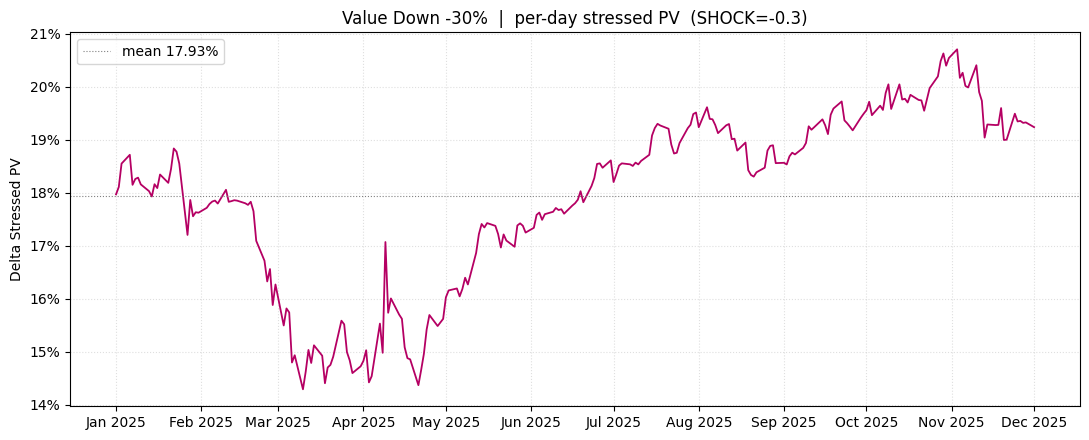

In [5]:
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(daily["date"], daily["delta"] * 100, color="#B50063", lw=1.3)
ax.axhline(daily["delta"].mean() * 100, color="grey", ls=":", lw=0.8,
           label=f"mean {daily.delta.mean()*100:.2f}%")
ax.set_ylabel("Delta Stressed PV")
ax.set_title(f"Value Down -30%  |  per-day stressed PV  (SHOCK={SHOCK})")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0f}%"))
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.grid(True, ls=":", alpha=0.4)
ax.legend()
fig.tight_layout(); plt.show()


In [6]:
mean_sec = sector.groupby("gics_name")["delta"].mean() * 100      # mean over days, in pp
order    = [s for s in gics_map.values() if s in mean_sec.index]
table    = mean_sec.reindex(order).to_frame("Value Down -30%")
table.loc["Total"] = daily["delta"].mean() * 100                  # = mean of per-day delta

print("STRESS_TEST_NAME: Risk DWH ST - Value Down -30%")
table.style.format("{:+.2f}%")


STRESS_TEST_NAME: Risk DWH ST - Value Down -30%


,Value Down -30%
gics_name,
Energy,-1.73%
Materials,-0.37%
Industrials,+0.22%
Consumer Discretionary,+1.98%
Consumer Staples,+0.57%
Health Care,+0.88%
Financials,-1.90%
Information Technology,+14.35%
Communication Services,+2.98%


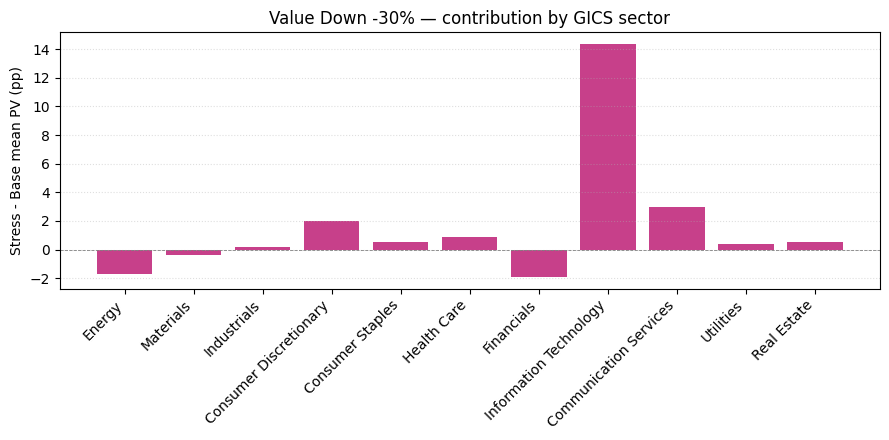

In [7]:
fig, ax = plt.subplots(figsize=(9, 4.5))
bars = ax.bar(order, mean_sec.reindex(order).values, color="#B50063", alpha=0.75)
ax.axhline(0, color="grey", lw=0.6, ls="--")
ax.set_ylabel("Stress - Base mean PV (pp)")
ax.set_title("Value Down -30% — contribution by GICS sector")
ax.grid(True, ls=":", alpha=0.4, axis="y")
plt.xticks(rotation=45, ha="right")
fig.tight_layout(); plt.show()
